# Maternal & Child Health Disparities Across Nigerian States

Pipeline: raw NDHS survey files → state-level indicators → PCA → K-Means clustering

**Data:** Nigeria Demographic and Health Survey (NDHS) 2023–2024 — Women's Recode (IR) and Children's Recode (KR) files. Source: [dhsprogram.com](https://dhsprogram.com/)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## 1. Load Raw DHS Files

IR = Individual (Women's) Recode: 39,050 women × 6,411 variables
KR = Children's Recode: 27,783 children × 1,331 variables

In [ ]:
women = pd.read_stata("NGIR8BFL.DTA")
children = pd.read_stata("NGKR8BFL.DTA")
print(women.shape, children.shape)

## 2. Construct Maternal Health Indicators

In [ ]:
# ANC 4+: at least 4 antenatal visits during most recent pregnancy
women["m14_clean"] = women["m14_1"].replace(98, np.nan)
women["anc_4plus"] = (women["m14_clean"] >= 4).astype(int)

# Skilled birth attendance: doctor OR nurse/midwife present at delivery
women["skilled_birth"] = (
    (women["m3a_1"] == 1) | (women["m3b_1"] == 1)
).astype(int)

# Modern family planning: currently using a modern contraceptive method
women["modern_fp"] = (women["v313"] == 3).astype(int)

# Facility delivery
facility_codes = [21, 22, 23, 24, 26, 27, 31, 32, 33, 34, 36]
women["facility_delivery"] = women["m15_1"].isin(facility_codes).astype(int)

## 3. Construct Child Health Indicators

In [ ]:
children["stunted"] = (children["hw70"] < -200).astype(int)
children["wasted"] = (children["hw72"] < -200).astype(int)
children["underweight"] = (children["hw71"] < -200).astype(int)
children["fever"] = (children["h22"] == 1).astype(int)

## 4. Aggregate to State Level

In [ ]:
state_maternal = women.groupby("sstate1").agg({
    "anc_4plus": "mean", "skilled_birth": "mean",
    "modern_fp": "mean", "facility_delivery": "mean",
})

state_child = children.groupby("sstate1").agg({
    "stunted": "mean", "wasted": "mean",
    "underweight": "mean", "fever": "mean",
})

final_data = state_maternal.merge(state_child, left_index=True, right_index=True)
final_data.head()

## 5. Standardize (Z-score)

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_data)

## 6. Principal Component Analysis

In [ ]:
pca = PCA()
pca_scores = pca.fit_transform(scaled_data)
explained_variance = pca.explained_variance_ratio_

loadings = pd.DataFrame(
    pca.components_.T, index=final_data.columns,
    columns=[f"PC{i+1}" for i in range(len(final_data.columns))],
)
print("Variance explained:", explained_variance)
loadings

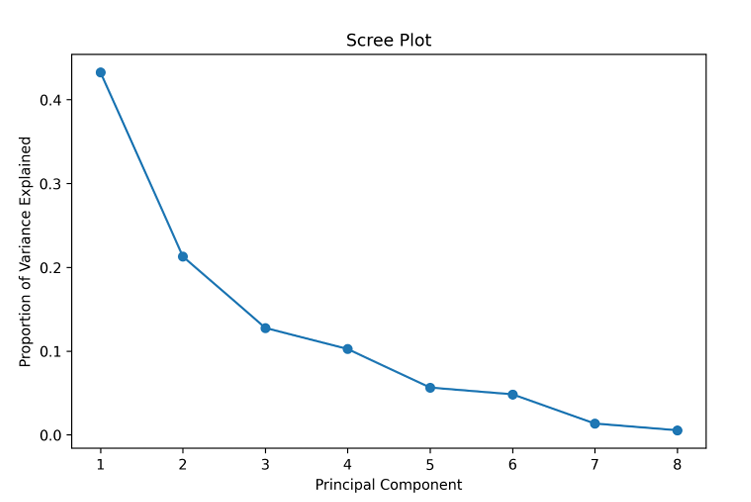

In [1]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.title("Scree Plot")
plt.grid(True)
plt.savefig("figures/scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. K-Means Clustering (k=3, on first 3 PCs → 77.35% variance)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_scores[:, :3])
final_data["cluster"] = clusters

state_clusters = final_data.reset_index()
cluster_summary = state_clusters.groupby("cluster")["sstate1"].apply(list)
print(cluster_summary)

cluster_profile = final_data.groupby("cluster").mean(numeric_only=True)
cluster_profile

## 8. Cluster Visualization

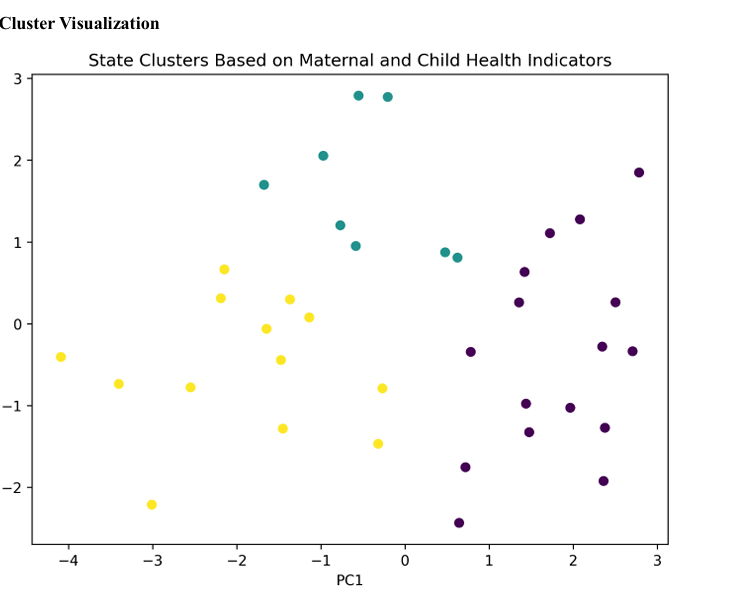

In [2]:
pca_df = pd.DataFrame(pca_scores[:, :2], columns=["PC1", "PC2"])

plt.figure(figsize=(8, 6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], c=clusters, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("State Clusters Based on Maternal and Child Health Indicators")
plt.savefig("figures/cluster_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Finding

States with strong antenatal care attendance don't always show the best child health outcomes — one cluster combines high ANC visits with the *highest* childhood fever prevalence of any group. Access to care isn't the same as protecting child health once families are home. That distinction matters for how health budgets get allocated.